# Getting Started with monod's Rust Extension

monod ships an optional compiled Rust extension (`monod_core`) that accelerates
three parts of the inference pipeline:

| Component | What it accelerates | Speed-up |
|---|---|---|
| **PSS evaluation** | Parallel FFT-based steady-state computation (rayon) | ~5–6× per grid point |
| **Data extraction** | Unique-histogram building from count matrices | ~10× |
| **L-BFGS-B optimizer** | Full optimisation loop in Rust — no Python callbacks | ~36× end-to-end at 1000 genes |

The first two are **automatic** — once `monod_core` is installed every call to
`CMEModel.eval_model_pss` and `extract_data` uses the fast path with no code changes.
The Rust optimizer requires one extra flag (`use_rust_lbfgsb=True`).

This notebook shows how to build the extension and run the full pipeline without
needing the optional `ruanndata` HDF5 reader.  If you later want to skip the Python
AnnData loading step entirely see the note at the end.

## 1  Building `monod_core`

`monod_core` is a [maturin](https://www.maturin.rs/)-managed Rust/PyO3 extension.
You need to build it once per Python environment.

### Step 1 — install the Rust toolchain

Skip if `rustc --version` already works in your terminal.

```bash
curl --proto '=https' --tlsv1.2 -sSf https://sh.rustup.rs | sh
source ~/.cargo/env          # or restart your terminal
```

### Step 2 — install maturin

```bash
pip install maturin
# conda users:
# conda install -c conda-forge maturin
```

### Step 3 — build and install `monod_core`

From the repository root:

```bash
cd monod_core
maturin develop --release
```

`--release` is important — the debug build is ~10× slower.

> **Apple Silicon (M-series) running an x86-64 Python under Rosetta:**  
> `maturin develop` targets the native arm64 ABI and will produce a binary
> incompatible with your Rosetta Python.  Build a wheel for the correct target
> instead:
> ```bash
> maturin build --release --target x86_64-apple-darwin -i $(which python3)
> pip install target/wheels/monod_core-*.whl
> ```

### Optional: build without the HDF5/ruanndata reader

If HDF5 is not available on your system you can build a lighter version that
omits the `searchdata_from_h5ad` and `load_histograms_h5ad` functions:

```bash
maturin develop --release --no-default-features
```

All other Rust fast-paths (PSS, optimizer, histogram extraction) are still included.

In [1]:
import importlib, subprocess, sys, os, pathlib
os.makedirs('figures', exist_ok=True)

def _try_run(*args):
    env = os.environ.copy()
    extra = [str(pathlib.Path.home() / ".cargo" / "bin"),
             str(pathlib.Path(sys.prefix) / "bin")]
    env["PATH"] = os.pathsep.join(extra) + os.pathsep + env.get("PATH", "")
    try:
        return subprocess.check_output(list(args), stderr=subprocess.DEVNULL,
                                       text=True, env=env).strip()
    except (FileNotFoundError, subprocess.CalledProcessError):
        return None


def check_rust_setup():
    spec = importlib.util.find_spec("monod_core")
    if spec is None:
        print("monod_core NOT found — Rust acceleration is disabled.")
        print()
        print("Build it with:")
        print("  cd monod_core && maturin develop --release")
        print()
        print("Then restart the kernel and re-run this cell.")
        return False

    import monod_core as _mc
    print(f"monod_core  : {_mc.__file__}")

    rustc   = _try_run("rustc", "--version")
    maturin = _try_run("maturin", "--version")
    print(f"rustc       : {rustc}"   if rustc   else "rustc       : not found (add ~/.cargo/bin to PATH to rebuild)")
    print(f"maturin     : {maturin}" if maturin else "maturin     : not found (pip install maturin to rebuild)")

    # Check which optional features were compiled in
    has_h5ad = hasattr(_mc, 'searchdata_from_h5ad')
    print(f"h5ad reader : {'enabled  (ruanndata feature)' if has_h5ad else 'disabled (built with --no-default-features)'}")
    print()
    print("Rust extension is ready.")
    return True


rust_ready = check_rust_setup()

monod_core  : /Users/ConradOakes/Library/r-miniconda/envs/monod/lib/python3.11/site-packages/monod_core/__init__.py
rustc       : rustc 1.94.0 (4a4ef493e 2026-03-02)
maturin     : maturin 1.12.6
h5ad reader : enabled  (ruanndata feature)

Rust extension is ready.


## 2  Imports and data

In [2]:
import sys, os, time, warnings
import numpy as np
import scipy.sparse
import matplotlib.pyplot as plt
import anndata as ad

warnings.filterwarnings('ignore')

_src = os.path.join(os.path.abspath('.'), 'src', 'monod')
if _src not in sys.path:
    sys.path.insert(0, _src)

from cme_toolbox import CMEModel, _HAS_RUST
from extract_data import extract_data
from inference import InferenceParameters, searchdata_from_adata
import monod_core as _mc

print(f"Rust extension loaded : {_HAS_RUST}")
print(f"monod_core version    : {getattr(_mc, '__version__', 'n/a')}")

Rust extension loaded : True
monod_core version    : n/a


In [3]:
# Load a small PBMC 10k dataset (spliced + unspliced counts)
H5AD_PATH = 'example_h5ad/processed_pbmc_10k_raw.h5ad'
adata_raw = ad.read_h5ad(H5AD_PATH)

# Select 50 genes expressed in ≥10 cells
s_mat = adata_raw.layers['spliced']
if scipy.sparse.issparse(s_mat):
    s_mat = s_mat.toarray()
expressed = np.where((s_mat > 0).sum(0) >= 10)[0]

N_GENES = 50
GENES   = list(adata_raw.var_names[expressed[:N_GENES]])
MODEL   = CMEModel('Bursty', 'Poisson')

print(f"Dataset : {adata_raw.n_obs} cells × {adata_raw.n_vars} genes")
print(f"Using   : {N_GENES} expressed genes")

The expected modalities for this model are: ['unspliced', 'spliced']
If your anndata layers have different names, please give a modality dictionary of the form: modality_name_dict  = {'spliced':your_spliced_layer_name, 'unspliced':your_unspliced_layer_name} 
Dataset : 10997 cells × 36601 genes
Using   : 50 expressed genes


## 3  Data loading: `extract_data` + `searchdata_from_adata`

The standard monod loading path works with any AnnData object and requires no
HDF5 reader.  When `monod_core` is installed, `searchdata_from_adata` automatically
returns a Rust `SearchData` object — the same type used internally by the Rust
optimizer — so the fast paths activate with no extra steps.

In [4]:
t0 = time.perf_counter()

# Step 1: extract histograms and moments from the AnnData object
adata_ext = extract_data(
    H5AD_PATH, MODEL,
    dataset_name='intro_demo',
    modality_name_dict={'unspliced': 'unspliced', 'spliced': 'spliced'},
    n_genes=len(GENES),
    genes_to_fit=GENES,
    hist_type='unique',
    viz=False,
)

# Step 2: convert to a SearchData container
#   - when monod_core is available this returns a Rust SearchData object
#   - otherwise it returns the pure-Python SearchData dataclass (same API)
search_data = searchdata_from_adata(adata_ext)

t_load = (time.perf_counter() - t0) * 1e3
print(f"Load time : {t_load:.0f} ms")
print(f"SearchData type : {type(search_data).__module__}.{type(search_data).__qualname__}")
print(f"  {search_data.n_genes} genes,  {search_data.n_cells} cells")

is sparse
5867 genes retained after expression filter.
Load time : 7280 ms
SearchData type : builtins.SearchData
  50 genes,  10997 cells


## 4  Rust PSS fast-path (automatic)

The Rust steady-state solver activates automatically for all supported models
(`Constitutive`, `Bursty`, `CIR`, `Extrinsic`, `Delay`, `DelayedSplicing`,
`ProteinBursty`) when `monod_core` is installed.  No code changes are needed.

The cell below runs inference with scipy L-BFGS-B and the default settings to
establish a baseline.

In [5]:
# Default inference: scipy L-BFGS-B, one gene at a time.
# gradient_params not specified — all defaults apply (num_restarts=3, init_pattern='moments', ...).
ip_scipy = InferenceParameters(
    'intro_demo', MODEL,
    use_lengths=False,
    gradient_params={'max_iterations': 200},
    gridsize=[3, 4],   # 12 sampling-rate grid points
    save=False,
)

t0 = time.perf_counter()
result_scipy = ip_scipy.fit_all_grid_points(search_data, num_cores=1, save=False)
t_scipy = time.perf_counter() - t0

result_scipy.find_sampling_optimum()
print(f"scipy (serial)  : {t_scipy:.2f} s  for {N_GENES} genes × 12 grid points")
print(f"Rust PSS active : {_HAS_RUST}")

Grid scan: 100%|██████████| 12/12 [00:10<00:00,  1.09it/s]

scipy (serial)  : 11.02 s  for 50 genes × 12 grid points
Rust PSS active : True


## 5  Rust L-BFGS-B optimizer

Setting `use_rust_lbfgsb=True` replaces the scipy callback-based loop with a
pure-Rust L-BFGS-B implementation (Cauchy point + subspace minimisation,
Moré–Thuente line search) that runs all genes in parallel via rayon.

Key differences from the scipy default:
- **No GIL round-trips** — the optimizer calls back into Rust PSS, not Python
- **Rayon outer parallelism** — all genes run simultaneously across CPU cores
- **`num_gene_cores=-1`** — tells the scheduler to use all available cores

In [6]:
# Rust L-BFGS-B: same defaults, two flags added.
#   use_rust_lbfgsb=True  — replace scipy optimizer with pure-Rust L-BFGS-B
#   num_gene_cores=-1     — parallelise across all CPU cores via rayon
ip_rust = InferenceParameters(
    'intro_demo', MODEL,
    use_lengths=False,
    gradient_params={
        'max_iterations' : 200,
        'num_gene_cores' : -1,
        'use_rust_lbfgsb': True,
    },
    gridsize=[3, 4],
    save=False,
)

t0 = time.perf_counter()
result_rust = ip_rust.fit_all_grid_points(search_data, num_cores=1, save=False)
t_rust = time.perf_counter() - t0

result_rust.find_sampling_optimum()
print(f"scipy (serial)      : {t_scipy:.2f} s")
print(f"Rust L-BFGS-B       : {t_rust:.2f} s")
print(f"Speedup             : {t_scipy/t_rust:.1f}×")

Grid scan: 100%|██████████| 12/12 [00:04<00:00,  2.94it/s]

scipy (serial)      : 11.02 s
Rust L-BFGS-B       : 4.09 s
Speedup             : 2.7×


## 6  Parameter concordance

Both optimizers share the same starting point (method-of-moments estimate) and
converge to the same model.  The scatter below compares the inferred biophysical
parameters gene-by-gene.  Points on the diagonal indicate identical solutions;
off-diagonal points reflect cases where the two optimizers found different local
minima (see the `demo_rusty_vs_main` notebook for a detailed analysis).

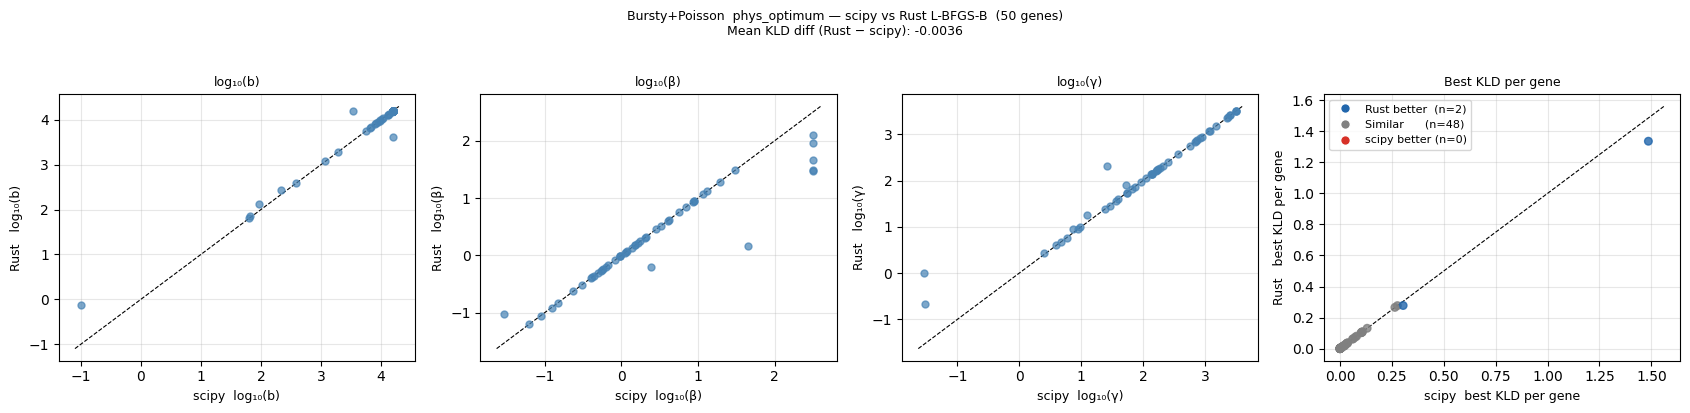

Rust better: 2  |  similar: 48  |  scipy better: 0
Mean KLD diff (Rust − scipy): -0.0036  (negative = Rust advantage)


In [7]:
p_sc = result_scipy.phys_optimum   # (n_genes, 3)  log10 [b, beta, gamma]
p_ru = result_rust.phys_optimum

k_sc = result_scipy.klds.min(axis=0)   # best KLD per gene across grid points
k_ru = result_rust.klds.min(axis=0)
kld_diff = k_ru - k_sc                 # positive = Rust worse

KLD_T = 0.01
n_better  = (kld_diff < -KLD_T).sum()
n_worse   = (kld_diff >  KLD_T).sum()
n_similar = N_GENES - n_better - n_worse

param_names = ['log₁₀(b)', 'log₁₀(β)', 'log₁₀(γ)']
C_RUST    = '#2166ac'
C_SCIPY   = '#d73027'
C_SIMILAR = 'grey'

fig, axes = plt.subplots(1, 4, figsize=(17, 4))

# ── Panels 1–3: parameter scatter ─────────────────────────────────────────────
for pi, (ax, name) in enumerate(zip(axes[:3], param_names)):
    lo = min(p_sc[:, pi].min(), p_ru[:, pi].min()) - 0.1
    hi = max(p_sc[:, pi].max(), p_ru[:, pi].max()) + 0.1
    ax.scatter(p_sc[:, pi], p_ru[:, pi], s=25, alpha=0.7, color='steelblue', zorder=3)
    ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8)
    ax.set_xlabel(f'scipy  {name}', fontsize=9)
    ax.set_ylabel(f'Rust   {name}', fontsize=9)
    ax.set_title(name, fontsize=9)
    ax.grid(True, alpha=0.3)

# ── Panel 4: KLD scatter ───────────────────────────────────────────────────────
ax = axes[3]
colors = [C_RUST if d < -KLD_T else (C_SCIPY if d > KLD_T else C_SIMILAR)
          for d in kld_diff]
ax.scatter(k_sc, k_ru, c=colors, s=30, alpha=0.8, zorder=3)
lo = min(k_sc.min(), k_ru.min()) * 0.95
hi = max(k_sc.max(), k_ru.max()) * 1.05
ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8)
ax.set_xlabel('scipy  best KLD per gene', fontsize=9)
ax.set_ylabel('Rust   best KLD per gene', fontsize=9)
ax.set_title('Best KLD per gene', fontsize=9)
ax.grid(True, alpha=0.3)

from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0],[0], marker='o', color='w', markerfacecolor=C_RUST,    ms=7, label=f'Rust better  (n={n_better})'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=C_SIMILAR, ms=7, label=f'Similar      (n={n_similar})'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=C_SCIPY,   ms=7, label=f'scipy better (n={n_worse})'),
], fontsize=8)

plt.suptitle(
    f'Bursty+Poisson  phys_optimum — scipy vs Rust L-BFGS-B  ({N_GENES} genes)\n'
    f'Mean KLD diff (Rust − scipy): {kld_diff.mean():.4f}',
    fontsize=9, y=1.02,
)
plt.tight_layout()
plt.savefig('figures/intro_rust_concordance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Rust better: {n_better}  |  similar: {n_similar}  |  scipy better: {n_worse}')
print(f'Mean KLD diff (Rust − scipy): {kld_diff.mean():.4f}  (negative = Rust advantage)')

## 7  Optional: skipping Python AnnData with `ruanndata`

If you have the `ruanndata` feature enabled (the default build), the function
`searchdata_from_h5ad` reads an `.h5ad` file, filters genes, and builds the
`SearchData` object entirely in Rust — no Python AnnData round-trip, no GIL
overhead:

```python
import monod_core as _mc

search_data = _mc.searchdata_from_h5ad(
    'path/to/data.h5ad',
    layer_names=['unspliced', 'spliced'],
    gene_names=my_gene_list,   # optional filter
)
```

This is the fastest possible loading path and is used in `demo_rusty_vs_main.ipynb`
for the end-to-end benchmarks.  However, it requires that `monod_core` was built
with the `ruanndata` feature (i.e. **not** `--no-default-features`) and that HDF5
is available on your system.

For portability — or if HDF5 is unavailable — the `extract_data` +
`searchdata_from_adata` path shown above gives identical inference results with
only a modest loading overhead.